# 01 Tesla Trading - Exploratory Data Analysis (EDA)

This notebook performs a deep audit of the `stock_tesla.csv` dataset. We explore the complexities of trading data, including stock splits, market correlation (SPY), and volatility regimes.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style='whitegrid', palette='muted')
%matplotlib inline

### Step 1: Loading & Temporal Normalization
**Action**: Load data and parse the chaotic `Date_Str` column.
**Why?**: Trading data uses Unix timestamps and ISO strings interchangeably. We must unify these to a proper `datetime` object to allow for time-series indexing.

In [6]:
def parse_date(val):
    if str(val).isdigit(): return pd.to_datetime(int(val), unit='s')
    return pd.to_datetime(val)

df = pd.read_csv('../_data/stock_tesla.csv')
df['Date'] = df['Date_Str'].apply(parse_date)
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")

Date Range: 2021-05-03 00:00:00 to 2026-04-30 00:00:00


### Step 2: Visualizing Stock Splits
**Action**: Plot the raw `Close` price and highlight the `Split_Factor` events.
**Why?**: Tesla had 5:1 and 3:1 splits. Looking at raw prices shows massive "cliffs" that aren't real market crashes. We must visualize these to justify our back-adjustment logic.

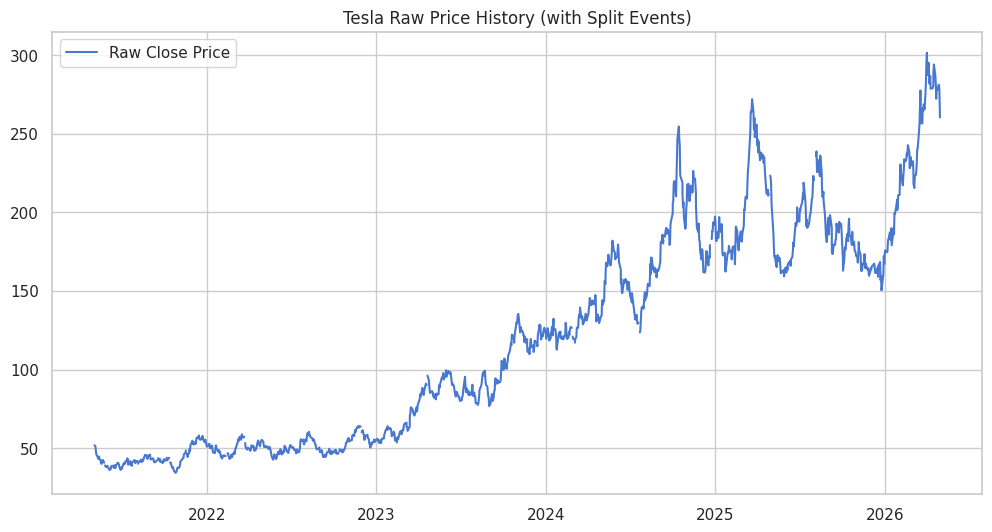

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Raw Close Price')
splits = df[df['Split_Factor'] > 1.0]
for idx, row in splits.iterrows():
    plt.annotate(f"Split {row['Split_Factor']}x", (row['Date'], row['Close']), 
                 xytext=(10, 20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title('Tesla Raw Price History (with Split Events)')
plt.legend()
plt.show()

### Step 3: Volatility & Market Correlation
**Action**: Compare Tesla returns to SPY returns.
**Why?**: Traders need to know if Tesla is moving with the market or independently. A correlation heatmap helps identify which technical indicators move together.

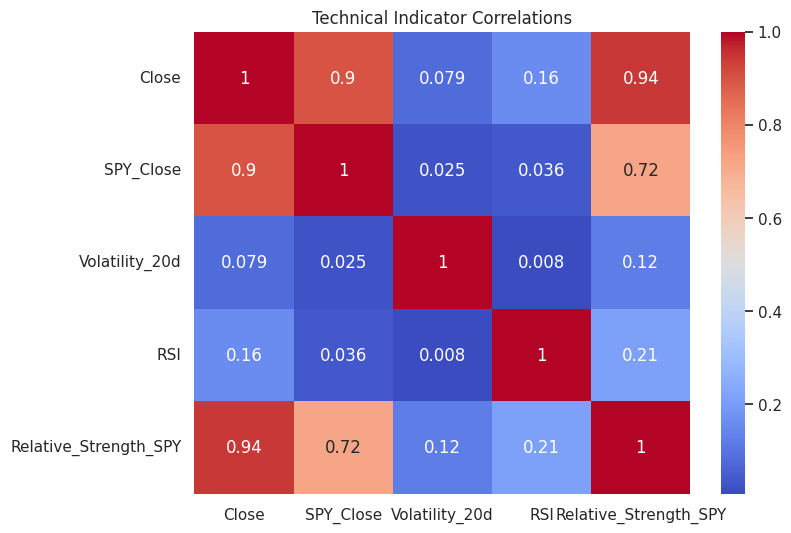

In [8]:
cols = ['Close', 'SPY_Close', 'Volatility_20d', 'RSI', 'Relative_Strength_SPY']
corr = df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Technical Indicator Correlations')
plt.show()

## Preprocessing Roadmap for Trading
1. **Adjust Prices**: Use `Split_Factor` to create an `Adj_Close` for clean trend analysis.
2. **Impute Outages**: Fix the `NaN` values injected during simulated market outages.
3. **Feature Scaling**: Normalize indicators like `Volume` and `RSI` for the Neural Networks.
4. **Sequence Creation**: Window the data into 30-day blocks for the LSTM.